# Graph I
Our first LangGraph graph!

In [ ]:
from typing import TypedDict   # 类型字典
from langgraph.graph import StateGraph   # 一个框架，帮助你设计和管理应用程序中的任务流程

In [2]:
# 创建智能体的状态 AgentState
# 什么是状态？一个共享的数据结构，它会跟踪应用程序运行时的所有信息

class AgentState(TypedDict):   # 将状态设置为类型字典的形式
    message : str 

# 定义节点，输入输出类型都必须是状态
def greeting_node(state: AgentState) -> AgentState:
    # 下面这一行称之为 文档字符串
    """Simple node that adds a greeting message to the state"""

    # 更新状态中的消息部分
    state['message'] = "Hey " + state["message"] + ", how is your day going?"

    return state   # 返回更新后的状态

In [3]:
graph = StateGraph(AgentState)    # 构建图，传入状态模式

graph.add_node("greeter", greeting_node)   # 传入节点的名称，和它将执行的操作

# 添加起点和终点
graph.set_entry_point("greeter")   # 传入键，即想让起点连接到的节点名称
graph.set_finish_point("greeter")

app = graph.compile()    # 编译图

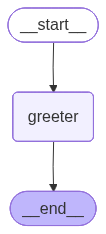

In [4]:
# 可视化图
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
# 运行图
result = app.invoke({"message": "Bob"})

In [6]:
result["message"]   # 某个特定属性

'Hey Bob, how is your day going?'